In [3]:
import pandas as pd
import numpy as np
import requests
import re

from io import StringIO

In [4]:
def clean_team_name(team):
    team = str(team)
    team = team.replace("\xa0", " ")
    
    # Remove parenthetical information
    team = re.sub(r"\s*\([^)]*\)", "", team)
    
    # Remove Wikipedia ranking/footnote markers
    team = team.replace("т", "")
    team = team.replace("*", "")
    
    # Clean extra whitespace
    team = " ".join(team.split())
    
    return team.strip()

In [5]:
def get_ap_rankings(year):
    url = f"https://en.wikipedia.org/wiki/{year}_NCAA_Division_I_FBS_football_rankings"
    
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 "
            "Chrome/131.0.0.0 Safari/537.36"
        )
    }
    
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    
    tables = pd.read_html(StringIO(response.text))
    
    # The AP Poll is the third table on these pages
    ap_table = tables[2]
    
    # Find preseason, final, and rank columns
    preseason_column = [
        col for col in ap_table.columns
        if str(col).startswith("Preseason")
    ][0]
    
    final_column = [
        col for col in ap_table.columns
        if "Final" in str(col)
    ][0]
    
    rank_column = ap_table.columns[0]
    
    # Preseason Top 25
    preseason = ap_table.iloc[:25][
        [rank_column, preseason_column]
    ].copy()
    
    preseason.columns = ["preseason_ap", "team"]
    preseason["team"] = preseason["team"].apply(clean_team_name)
    
    # Final Top 25
    final = ap_table.iloc[:25][
        [rank_column, final_column]
    ].copy()
    
    final.columns = ["final_ap_rank", "team"]
    final["team"] = final["team"].apply(clean_team_name)
    
    # Match teams appearing in either poll
    result = pd.merge(
        preseason,
        final,
        on="team",
        how="outer"
    )
    
    result["season"] = year
    
    result = result[
        [
            "season",
            "team",
            "preseason_ap",
            "final_ap_rank"
        ]
    ]
    
    return result

In [6]:
all_ap = []

for year in range(2014, 2026):
    try:
        season_data = get_ap_rankings(year)
        all_ap.append(season_data)
        print(f"{year}: {len(season_data)} teams")
    except Exception as e:
        print(f"ERROR for {year}: {e}")

ap_data = pd.concat(all_ap, ignore_index=True)

2014: 34 teams
2015: 35 teams
2016: 36 teams
2017: 34 teams
2018: 36 teams
2019: 33 teams
2020: 35 teams
2021: 39 teams
2022: 40 teams
2023: 33 teams
2024: 38 teams
2025: 37 teams


In [7]:
previous_ap = ap_data[
    ["season", "team", "final_ap_rank"]
].copy()

previous_ap["season"] = previous_ap["season"] + 1

previous_ap = previous_ap.rename(
    columns={
        "final_ap_rank": "previous_final_ap"
    }
)

ap_data = ap_data.merge(
    previous_ap,
    on=["season", "team"],
    how="left"
)

In [8]:
ap_2013 = get_ap_rankings(2013)

previous_2013 = ap_2013[
    ["team", "final_ap_rank"]
].copy()

previous_2013 = previous_2013.rename(
    columns={
        "final_ap_rank": "previous_final_ap"
    }
)

previous_2013_dict = dict(
    zip(
        previous_2013["team"],
        previous_2013["previous_final_ap"]
    )
)

ap_data.loc[
    ap_data["season"] == 2014,
    "previous_final_ap"
] = (
    ap_data.loc[
        ap_data["season"] == 2014,
        "team"
    ].map(previous_2013_dict)
)

In [9]:
print(ap_data.head(20).to_string(index=False))

print("\nShape:", ap_data.shape)

print("\nDuplicate team-seasons:")
print(
    ap_data.duplicated(
        ["season", "team"]
    ).sum()
)

print("\nMissing values:")
print(ap_data.isna().sum())

 season              team  preseason_ap  final_ap_rank  previous_final_ap
   2014           Alabama           2.0            4.0                7.0
   2014           Arizona           NaN           19.0                NaN
   2014     Arizona State          19.0           12.0               21.0
   2014            Auburn           6.0           22.0                2.0
   2014            Baylor          10.0            7.0               13.0
   2014       Boise State           NaN           16.0                NaN
   2014           Clemson          16.0           15.0                8.0
   2014     Florida State           1.0            5.0                1.0
   2014           Georgia          12.0            9.0                NaN
   2014      Georgia Tech           NaN            8.0                NaN
   2014      Kansas State          20.0           18.0                NaN
   2014               LSU          13.0            NaN               14.0
   2014        Louisville           Na

In [10]:
print(
    ap_data[
        ap_data["team"] == "Alabama"
    ].sort_values("season").to_string(index=False)
)

 season    team  preseason_ap  final_ap_rank  previous_final_ap
   2014 Alabama           2.0            4.0                7.0
   2015 Alabama           3.0            1.0                4.0
   2016 Alabama           1.0            2.0                1.0
   2017 Alabama           1.0            1.0                2.0
   2018 Alabama           1.0            2.0                1.0
   2019 Alabama           2.0            8.0                2.0
   2020 Alabama           3.0            1.0                8.0
   2021 Alabama           1.0            2.0                1.0
   2022 Alabama           1.0            5.0                2.0
   2023 Alabama           4.0            5.0                5.0
   2024 Alabama           5.0           17.0                5.0
   2025 Alabama           8.0            9.0               17.0


In [11]:
def get_team_wins(year):
    url = (
        "https://site.api.espn.com/apis/v2/sports/"
        "football/college-football/standings"
    )

    params = {
        "season": year
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    records = []

    for group in data["children"]:

        # Skip groups that do not contain standings
        if "standings" not in group:
            continue

        if "entries" not in group["standings"]:
            continue

        for entry in group["standings"]["entries"]:

            team = entry["team"]["displayName"]

            overall_record = next(
                (
                    stat for stat in entry["stats"]
                    if stat.get("name") == "overall"
                ),
                None
            )

            # Skip teams without an overall record
            if overall_record is None:
                continue

            wins = int(
                overall_record["summary"].split("-")[0]
            )

            records.append({
                "season": year,
                "team": team,
                "wins": wins
            })

    return pd.DataFrame(records)


wins_2024 = get_team_wins(2024)

print("Teams found:", len(wins_2024))
print()
print(wins_2024.head(20).to_string(index=False))

print("\nTest teams:")

print(
    wins_2024[
        wins_2024["team"].str.contains(
            "Alabama|Georgia|Charlotte",
            case=False,
            regex=True
        )
    ].to_string(index=False)
)

Teams found: 120

 season                   team  wins
   2024     Army Black Knights    12
   2024         Memphis Tigers    11
   2024        Navy Midshipmen    10
   2024      Tulane Green Wave     9
   2024  East Carolina Pirates     8
   2024    South Florida Bulls     7
   2024       UTSA Roadrunners     7
   2024 North Texas Mean Green     6
   2024        Charlotte 49ers     5
   2024              Rice Owls     4
   2024            Temple Owls     3
   2024            UAB Blazers     3
   2024  Florida Atlantic Owls     3
   2024 Tulsa Golden Hurricane     3
   2024           SMU Mustangs    11
   2024       Miami Hurricanes    10
   2024        Syracuse Orange    10
   2024         Clemson Tigers    10
   2024   Louisville Cardinals     9
   2024       Duke Blue Devils     9

Test teams:
 season                        team  wins
   2024             Charlotte 49ers     5
   2024 Georgia Tech Yellow Jackets     7
   2024            Georgia Bulldogs    11
   2024        Alabama C

In [12]:
playoff_teams = {
    2014: [
        "Alabama", "Oregon", "Florida State", "Ohio State"
    ],
    2015: [
        "Clemson", "Alabama", "Michigan State", "Oklahoma"
    ],
    2016: [
        "Alabama", "Clemson", "Ohio State", "Washington"
    ],
    2017: [
        "Clemson", "Oklahoma", "Georgia", "Alabama"
    ],
    2018: [
        "Alabama", "Clemson", "Notre Dame", "Oklahoma"
    ],
    2019: [
        "LSU", "Ohio State", "Clemson", "Oklahoma"
    ],
    2020: [
        "Alabama", "Clemson", "Ohio State", "Notre Dame"
    ],
    2021: [
        "Alabama", "Michigan", "Georgia", "Cincinnati"
    ],
    2022: [
        "Georgia", "Michigan", "Ohio State", "TCU"
    ],
    2023: [
        "Michigan", "Washington", "Texas", "Alabama"
    ],
    2024: [
        "Oregon", "Georgia", "Boise State", "Arizona State",
        "Penn State", "Notre Dame", "Ohio State", "Texas",
        "Clemson", "Indiana", "Tennessee", "SMU"
    ],
    2025: [
        "Indiana", "Ohio State", "Georgia", "Texas Tech",
        "Oregon", "Ole Miss", "Texas A&M", "Oklahoma",
        "Alabama", "Miami", "Tulane", "James Madison"
    ],
}

ap_data["made_playoff"] = ap_data.apply(
    lambda row: int(
        row["team"] in playoff_teams.get(row["season"], [])
    ),
    axis=1
)

In [13]:
ap_data["made_playoff"] = ap_data.apply(
    lambda row: int(
        row["team"] in playoff_teams.get(row["season"], [])
    ),
    axis=1
)

print(
    ap_data[
        ap_data["made_playoff"] == 1
    ].sort_values(["season", "final_ap_rank"]).to_string(index=False)
)

 season           team  preseason_ap  final_ap_rank  previous_final_ap  made_playoff
   2014     Ohio State           5.0            1.0               12.0             1
   2014         Oregon           3.0            2.0                9.0             1
   2014        Alabama           2.0            4.0                7.0             1
   2014  Florida State           1.0            5.0                1.0             1
   2015        Alabama           3.0            1.0                4.0             1
   2015        Clemson          12.0            2.0               15.0             1
   2015       Oklahoma          19.0            5.0                NaN             1
   2015 Michigan State           5.0            6.0                6.0             1
   2016        Clemson           2.0            1.0                2.0             1
   2016        Alabama           1.0            2.0                1.0             1
   2016     Washington          14.0            4.0              

In [14]:
print("Dataset shape:", ap_data.shape)

print("\nColumns:")
print(ap_data.columns.tolist())

print("\nMissing values:")
print(ap_data.isna().sum())

print("\nPlayoff teams by season:")
print(
    ap_data.groupby("season")["made_playoff"]
    .sum()
)

print("\nRows with a final AP ranking:")
print(
    ap_data["final_ap_rank"].notna().sum()
)

print("\nRows with a preseason AP ranking:")
print(
    ap_data["preseason_ap"].notna().sum()
)

Dataset shape: (430, 6)

Columns:
['season', 'team', 'preseason_ap', 'final_ap_rank', 'previous_final_ap', 'made_playoff']

Missing values:
season                 0
team                   0
preseason_ap         130
final_ap_rank        130
previous_final_ap    186
made_playoff           0
dtype: int64

Playoff teams by season:
season
2014     4
2015     4
2016     4
2017     4
2018     4
2019     4
2020     4
2021     4
2022     4
2023     4
2024    12
2025    12
Name: made_playoff, dtype: int64

Rows with a final AP ranking:
300

Rows with a preseason AP ranking:
300


In [15]:
regression_data = ap_data[
    ap_data["final_ap_rank"].notna()
].copy()

print("Regression rows:", len(regression_data))

print("\nMissing values:")
print(regression_data.isna().sum())

print("\nFirst 10 rows:")
print(
    regression_data.head(10).to_string(index=False)
)

Regression rows: 300

Missing values:
season                 0
team                   0
preseason_ap         130
final_ap_rank          0
previous_final_ap    154
made_playoff           0
dtype: int64

First 10 rows:
 season          team  preseason_ap  final_ap_rank  previous_final_ap  made_playoff
   2014       Alabama           2.0            4.0                7.0             1
   2014       Arizona           NaN           19.0                NaN             0
   2014 Arizona State          19.0           12.0               21.0             0
   2014        Auburn           6.0           22.0                2.0             0
   2014        Baylor          10.0            7.0               13.0             0
   2014   Boise State           NaN           16.0                NaN             0
   2014       Clemson          16.0           15.0                8.0             0
   2014 Florida State           1.0            5.0                1.0             1
   2014       Georgia      

In [16]:
regression_data["preseason_ap"] = (
    regression_data["preseason_ap"]
    .fillna(26)
)

regression_data["previous_final_ap"] = (
    regression_data["previous_final_ap"]
    .fillna(26)
)

X = regression_data[
    ["preseason_ap", "previous_final_ap"]
]

y = regression_data["final_ap_rank"]

print("Features:")
print(X.head(10))

print("\nTarget:")
print(y.head(10))

print("\nRemaining missing values:")
print(X.isna().sum())

Features:
   preseason_ap  previous_final_ap
0           2.0                7.0
1          26.0               26.0
2          19.0               21.0
3           6.0                2.0
4          10.0               13.0
5          26.0               26.0
6          16.0                8.0
7           1.0                1.0
8          12.0               26.0
9          26.0               26.0

Target:
0     4.0
1    19.0
2    12.0
3    22.0
4     7.0
5    16.0
6    15.0
7     5.0
8     9.0
9     8.0
Name: final_ap_rank, dtype: float64

Remaining missing values:
preseason_ap         0
previous_final_ap    0
dtype: int64


In [17]:
train_data = regression_data[
    regression_data["season"] <= 2022
].copy()

validation_data = regression_data[
    regression_data["season"].isin([2023, 2024])
].copy()

test_data = regression_data[
    regression_data["season"] == 2025
].copy()

X_train = train_data[
    ["preseason_ap", "previous_final_ap"]
]

y_train = train_data["final_ap_rank"]

X_validation = validation_data[
    ["preseason_ap", "previous_final_ap"]
]

y_validation = validation_data["final_ap_rank"]

X_test = test_data[
    ["preseason_ap", "previous_final_ap"]
]

y_test = test_data["final_ap_rank"]

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Test rows:", len(test_data))

Training rows: 225
Validation rows: 50
Test rows: 25


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_prediction = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    baseline_prediction
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline prediction:", round(baseline_prediction, 2))
print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R²:", round(baseline_r2, 3))

Baseline prediction: 13.0
Baseline MAE: 6.24
Baseline RMSE: 7.21
Baseline R²: 0.0


In [19]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("-----------------")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 3))

Linear Regression
-----------------
MAE: 4.68
RMSE: 5.87
R²: 0.337


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Regression")
print("------------------------")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²:", round(rf_r2, 3))

Random Forest Regression
------------------------
MAE: 5.33
RMSE: 6.87
R²: 0.091


In [21]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

print(coefficients)

print("\nIntercept:", round(linear_model.intercept_, 3))

             Feature  Coefficient
0       preseason_ap     0.408869
1  previous_final_ap     0.025520

Intercept: 5.497


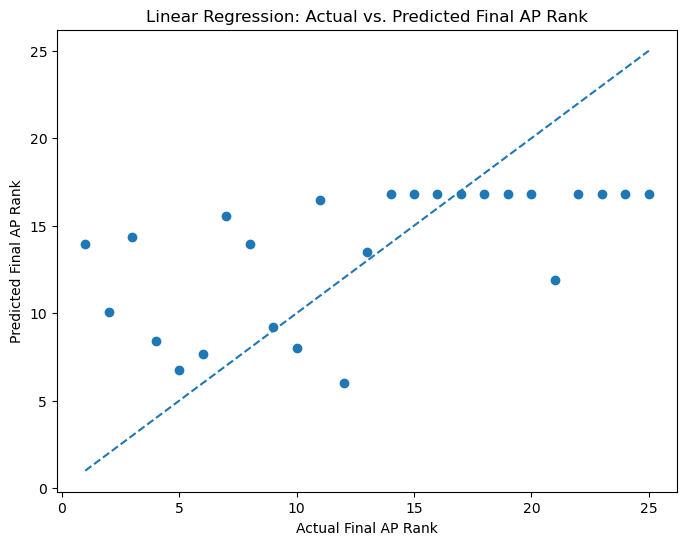

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions
)

plt.plot(
    [1, 25],
    [1, 25],
    linestyle="--"
)

plt.xlabel("Actual Final AP Rank")
plt.ylabel("Predicted Final AP Rank")
plt.title("Linear Regression: Actual vs. Predicted Final AP Rank")

plt.show()

In [23]:
classification_data = ap_data.copy()

classification_data["preseason_ap"] = (
    classification_data["preseason_ap"]
    .fillna(26)
)

classification_data["previous_final_ap"] = (
    classification_data["previous_final_ap"]
    .fillna(26)
)

X_class = classification_data[
    ["preseason_ap", "previous_final_ap"]
]

y_class = classification_data["made_playoff"]

print("Classification rows:", len(classification_data))

print("\nClass counts:")
print(y_class.value_counts())

print("\nClass proportions:")
print(y_class.value_counts(normalize=True))

Classification rows: 430

Class counts:
made_playoff
0    366
1     64
Name: count, dtype: int64

Class proportions:
made_playoff
0    0.851163
1    0.148837
Name: proportion, dtype: float64


In [24]:
train_class = classification_data[
    classification_data["season"] <= 2022
].copy()

validation_class = classification_data[
    classification_data["season"].isin([2023, 2024])
].copy()

test_class = classification_data[
    classification_data["season"] == 2025
].copy()

X_train_class = train_class[
    ["preseason_ap", "previous_final_ap"]
]

y_train_class = train_class["made_playoff"]

X_validation_class = validation_class[
    ["preseason_ap", "previous_final_ap"]
]

y_validation_class = validation_class["made_playoff"]

X_test_class = test_class[
    ["preseason_ap", "previous_final_ap"]
]

y_test_class = test_class["made_playoff"]

print("Training rows:", len(train_class))
print("Validation rows:", len(validation_class))
print("Test rows:", len(test_class))

print("\nPlayoff teams in each set:")
print("Training:", y_train_class.sum())
print("Validation:", y_validation_class.sum())
print("Test:", y_test_class.sum())

Training rows: 322
Validation rows: 71
Test rows: 37

Playoff teams in each set:
Training: 36
Validation: 16
Test: 12


In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

baseline_classifier = DummyClassifier(
    strategy="most_frequent"
)

baseline_classifier.fit(
    X_train_class,
    y_train_class
)

baseline_class_predictions = (
    baseline_classifier.predict(X_test_class)
)

print("Classification Baseline")
print("-----------------------")
print("Accuracy:", round(
    accuracy_score(
        y_test_class,
        baseline_class_predictions
    ), 3
))

print("Precision:", round(
    precision_score(
        y_test_class,
        baseline_class_predictions,
        zero_division=0
    ), 3
))

print("Recall:", round(
    recall_score(
        y_test_class,
        baseline_class_predictions,
        zero_division=0
    ), 3
))

print("F1:", round(
    f1_score(
        y_test_class,
        baseline_class_predictions,
        zero_division=0
    ), 3
))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        baseline_class_predictions
    )
)

Classification Baseline
-----------------------
Accuracy: 0.676
Precision: 0.0
Recall: 0.0
F1: 0.0

Confusion Matrix:
[[25  0]
 [12  0]]


In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_class,
    y_train_class
)

logistic_predictions = logistic_model.predict(
    X_test_class
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_class
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test_class,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test_class,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test_class,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_class,
    logistic_predictions,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test_class,
    logistic_probabilities
)

print("Logistic Regression")
print("-------------------")
print("Accuracy:", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall:", round(logistic_recall, 3))
print("F1:", round(logistic_f1, 3))
print("ROC-AUC:", round(logistic_auc, 3))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        logistic_predictions
    )
)

Logistic Regression
-------------------
Accuracy: 0.649
Precision: 0.455
Recall: 0.417
F1: 0.435
ROC-AUC: 0.6

Confusion Matrix:
[[19  6]
 [ 7  5]]


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3,
    class_weight="balanced"
)

rf_classifier.fit(
    X_train_class,
    y_train_class
)

rf_class_predictions = rf_classifier.predict(
    X_test_class
)

rf_class_probabilities = rf_classifier.predict_proba(
    X_test_class
)[:, 1]

rf_class_accuracy = accuracy_score(
    y_test_class,
    rf_class_predictions
)

rf_class_precision = precision_score(
    y_test_class,
    rf_class_predictions,
    zero_division=0
)

rf_class_recall = recall_score(
    y_test_class,
    rf_class_predictions,
    zero_division=0
)

rf_class_f1 = f1_score(
    y_test_class,
    rf_class_predictions,
    zero_division=0
)

rf_class_auc = roc_auc_score(
    y_test_class,
    rf_class_probabilities
)

print("Random Forest Classifier")
print("------------------------")
print("Accuracy:", round(rf_class_accuracy, 3))
print("Precision:", round(rf_class_precision, 3))
print("Recall:", round(rf_class_recall, 3))
print("F1:", round(rf_class_f1, 3))
print("ROC-AUC:", round(rf_class_auc, 3))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        rf_class_predictions
    )
)

Random Forest Classifier
------------------------
Accuracy: 0.622
Precision: 0.375
Recall: 0.25
F1: 0.3
ROC-AUC: 0.487

Confusion Matrix:
[[20  5]
 [ 9  3]]


In [28]:
logistic_coefficients = pd.DataFrame({
    "Feature": X_train_class.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Odds_Ratio"] = np.exp(
    logistic_coefficients["Coefficient"]
)

print(logistic_coefficients)

             Feature  Coefficient  Odds_Ratio
0       preseason_ap    -0.182205    0.833430
1  previous_final_ap    -0.003462    0.996544


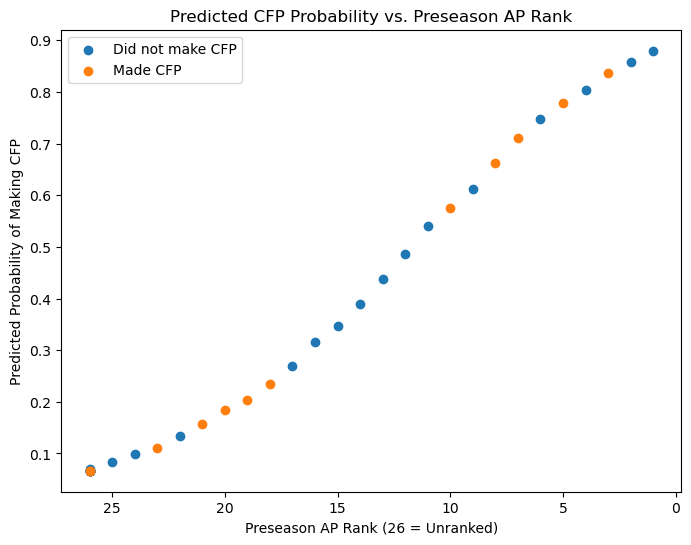

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_class.loc[y_test_class == 0, "preseason_ap"],
    logistic_probabilities[y_test_class.values == 0],
    label="Did not make CFP"
)

plt.scatter(
    X_test_class.loc[y_test_class == 1, "preseason_ap"],
    logistic_probabilities[y_test_class.values == 1],
    label="Made CFP"
)

plt.xlabel("Preseason AP Rank (26 = Unranked)")
plt.ylabel("Predicted Probability of Making CFP")
plt.title("Predicted CFP Probability vs. Preseason AP Rank")

plt.gca().invert_xaxis()
plt.legend()

plt.show()

In [30]:
# Regression: evaluate models on the validation set

linear_validation_predictions = linear_model.predict(X_validation)
rf_validation_predictions = rf_model.predict(X_validation)

validation_regression_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(
            y_validation,
            np.full(len(y_validation), y_train.mean())
        ),
        mean_absolute_error(
            y_validation,
            linear_validation_predictions
        ),
        mean_absolute_error(
            y_validation,
            rf_validation_predictions
        )
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(
            y_validation,
            np.full(len(y_validation), y_train.mean())
        )),
        np.sqrt(mean_squared_error(
            y_validation,
            linear_validation_predictions
        )),
        np.sqrt(mean_squared_error(
            y_validation,
            rf_validation_predictions
        ))
    ],
    "R²": [
        r2_score(
            y_validation,
            np.full(len(y_validation), y_train.mean())
        ),
        r2_score(
            y_validation,
            linear_validation_predictions
        ),
        r2_score(
            y_validation,
            rf_validation_predictions
        )
    ]
})

validation_regression_results

,Model,MAE,RMSE,R²
0,Baseline,6.240000,7.211103,0.000000
1,Linear Regression,5.007968,5.712125,0.372531
2,Random Forest,5.218166,6.163234,0.269511


In [31]:
# Classification: evaluate models on the validation set

logistic_validation_predictions = logistic_model.predict(X_validation_class)
logistic_validation_probabilities = logistic_model.predict_proba(
    X_validation_class
)[:, 1]

rf_class_validation_predictions = rf_classifier.predict(X_validation_class)
rf_class_validation_probabilities = rf_classifier.predict_proba(
    X_validation_class
)[:, 1]

baseline_class_validation_predictions = baseline_classifier.predict(
    X_validation_class
)

validation_classification_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(
            y_validation_class,
            baseline_class_validation_predictions
        ),
        accuracy_score(
            y_validation_class,
            logistic_validation_predictions
        ),
        accuracy_score(
            y_validation_class,
            rf_class_validation_predictions
        )
    ],
    "Precision": [
        precision_score(
            y_validation_class,
            baseline_class_validation_predictions,
            zero_division=0
        ),
        precision_score(
            y_validation_class,
            logistic_validation_predictions,
            zero_division=0
        ),
        precision_score(
            y_validation_class,
            rf_class_validation_predictions,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_validation_class,
            baseline_class_validation_predictions,
            zero_division=0
        ),
        recall_score(
            y_validation_class,
            logistic_validation_predictions,
            zero_division=0
        ),
        recall_score(
            y_validation_class,
            rf_class_validation_predictions,
            zero_division=0
        )
    ],
    "F1": [
        f1_score(
            y_validation_class,
            baseline_class_validation_predictions,
            zero_division=0
        ),
        f1_score(
            y_validation_class,
            logistic_validation_predictions,
            zero_division=0
        ),
        f1_score(
            y_validation_class,
            rf_class_validation_predictions,
            zero_division=0
        )
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_validation_class,
            baseline_classifier.predict_proba(X_validation_class)[:, 1]
        ),
        roc_auc_score(
            y_validation_class,
            logistic_validation_probabilities
        ),
        roc_auc_score(
            y_validation_class,
            rf_class_validation_probabilities
        )
    ]
})

validation_classification_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.774648,0.000000,0.000,0.000000,0.500000
1,Logistic Regression,0.746479,0.454545,0.625,0.526316,0.705114
2,Random Forest,0.788732,0.545455,0.375,0.444444,0.642614


In [32]:
# Combine training and validation data
regression_train_full = regression_data[
    regression_data["season"] <= 2024
].copy()

classification_train_full = classification_data[
    classification_data["season"] <= 2024
].copy()

# -----------------------------
# Final Regression Model
# -----------------------------

X_train_full = regression_train_full[
    ["preseason_ap", "previous_final_ap"]
]
y_train_full = regression_train_full["final_ap_rank"]

final_linear_model = LinearRegression()
final_linear_model.fit(X_train_full, y_train_full)

final_regression_predictions = final_linear_model.predict(X_test)

final_regression_results = {
    "MAE": mean_absolute_error(
        y_test,
        final_regression_predictions
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            final_regression_predictions
        )
    ),
    "R²": r2_score(
        y_test,
        final_regression_predictions
    )
}

print("Final Linear Regression Results:")
for metric, value in final_regression_results.items():
    print(f"{metric}: {value:.3f}")


# -----------------------------
# Final Classification Model
# -----------------------------

X_class_train_full = classification_train_full[
    ["preseason_ap", "previous_final_ap"]
]
y_class_train_full = classification_train_full["made_playoff"]

final_logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

final_logistic_model.fit(
    X_class_train_full,
    y_class_train_full
)

final_class_predictions = final_logistic_model.predict(
    X_test_class
)

final_class_probabilities = final_logistic_model.predict_proba(
    X_test_class
)[:, 1]

final_classification_results = {
    "Accuracy": accuracy_score(
        y_test_class,
        final_class_predictions
    ),
    "Precision": precision_score(
        y_test_class,
        final_class_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_class,
        final_class_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_class,
        final_class_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_class,
        final_class_probabilities
    )
}

print("\nFinal Logistic Regression Results:")
for metric, value in final_classification_results.items():
    print(f"{metric}: {value:.3f}")

Final Linear Regression Results:
MAE: 4.701
RMSE: 5.935
R²: 0.323

Final Logistic Regression Results:
Accuracy: 0.595
Precision: 0.385
Recall: 0.417
F1: 0.400
ROC-AUC: 0.607


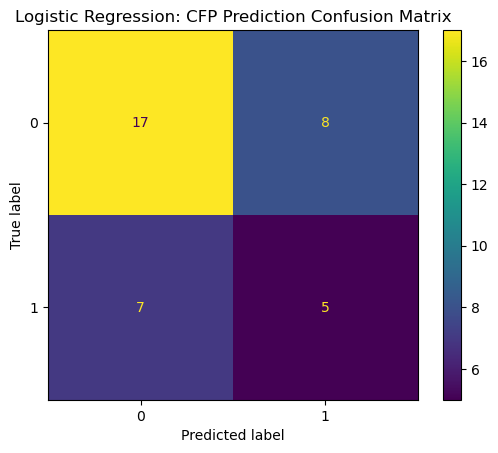

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    final_class_predictions
)

plt.title("Logistic Regression: CFP Prediction Confusion Matrix")
plt.show()

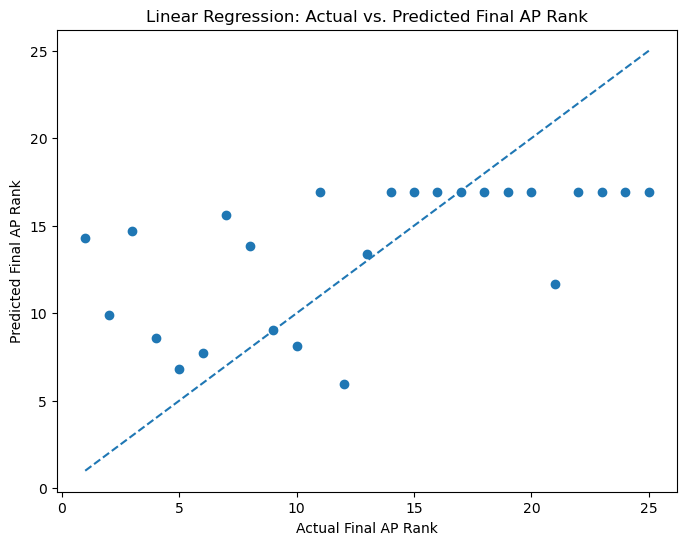

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_regression_predictions
)

plt.plot(
    [1, 25],
    [1, 25],
    linestyle="--"
)

plt.xlabel("Actual Final AP Rank")
plt.ylabel("Predicted Final AP Rank")
plt.title("Linear Regression: Actual vs. Predicted Final AP Rank")

plt.show()

In [36]:
# Get the 2026 preseason AP poll

url = "https://en.wikipedia.org/wiki/2026_NCAA_Division_I_FBS_football_rankings"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "Chrome/131.0.0.0 Safari/537.36"
    )
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables_2026 = pd.read_html(StringIO(response.text))

print(len(tables_2026))

for i, table in enumerate(tables_2026):
    print(i, table.shape, table.columns)

9
0 (4, 2) Index(['2026 NCAA Division I FBS football rankings', '2026 NCAA Division I FBS football rankings.1'], dtype='object')
1 (7, 3) Index([0, 1, 2], dtype='int64')
2 (27, 18) Index(['Unnamed: 0', 'Preseason Aug 17[1]', 'Week 1 Sept 8[2]',
       'Week 2 Sept 13[3]', 'Week 3 Sept 20[4]', 'Week 4 Sept 27[5]',
       'Week 5 Oct 4', 'Week 6 Oct 11', 'Week 7 Oct 18', 'Week 8 Oct 25',
       'Week 9 Nov 1', 'Week 10 Nov 8', 'Week 11 Nov 15', 'Week 12 Nov 22',
       'Week 13 Nov 29', 'Week 14 Dec 6', 'Week 15 (Final) Jan 26',
       'Unnamed: 17'],
      dtype='object')
3 (27, 18) Index(['Unnamed: 0', 'Preseason Aug 4[11]', 'Week 1 Sept 8[12]',
       'Week 2 Sept 13[13]', 'Week 3 Sept 20[14]', 'Week 4 Sept 27[15]',
       'Week 5 Oct 4', 'Week 6 Oct 11', 'Week 7 Oct 18', 'Week 8 Oct 25',
       'Week 9 Nov 1', 'Week 10 Nov 8', 'Week 11 Nov 15', 'Week 12 Nov 22',
       'Week 13 Nov 29', 'Week 14 Dec 6', 'Week 15 (Final) Jan 26',
       'Unnamed: 17'],
      dtype='object')
4 (1, 8) M

In [37]:
# Extract the 2026 preseason AP Top 25

ap_2026_table = tables_2026[2].copy()

# Display the first few rows to verify the structure
print(ap_2026_table.head(30).to_string(index=False))

 Unnamed: 0 Preseason Aug 17[1]        Week 1 Sept 8[2]         Week 2 Sept 13[3]                     Week 3 Sept 20[4]                                                      Week 4 Sept 27[5] Week 5 Oct 4 Week 6 Oct 11 Week 7 Oct 18 Week 8 Oct 25 Week 9 Nov 1 Week 10 Nov 8 Week 11 Nov 15 Week 12 Nov 22 Week 13 Nov 29 Week 14 Dec 6 Week 15 (Final) Jan 26  Unnamed: 17
        1.0     Ohio State (40)   Ohio State (1–0) (46)          Texas (2–0) (56)                      Texas (3–0) (58)                                                       Texas (4–0) (62)          NaN           NaN           NaN           NaN          NaN           NaN            NaN            NaN            NaN           NaN                    NaN          1.0
        2.0         Oregon (14)           Georgia (1–0)         Georgia (2–0) (3)                     Georgia (3–0) (3)                                                      Georgia (4–0) (6)          NaN           NaN           NaN           NaN          NaN      

In [38]:
# Build 2026 preseason dataset

preseason_2026 = ap_2026_table[
    ["Unnamed: 0", "Preseason Aug 17[1]"]
].copy()

preseason_2026.columns = ["rank", "team"]

# Keep only the 25 ranked teams
preseason_2026 = preseason_2026[
    preseason_2026["rank"].notna()
].copy()

preseason_2026["rank"] = preseason_2026["rank"].astype(int)

preseason_2026["team"] = (
    preseason_2026["team"]
    .apply(clean_team_name)
)

preseason_2026 = preseason_2026.rename(
    columns={"rank": "preseason_ap"}
)

# Get each team's 2025 final AP ranking
previous_2026 = ap_data[
    ap_data["season"] == 2025
][
    ["team", "final_ap_rank"]
].copy()

previous_2026 = previous_2026.rename(
    columns={"final_ap_rank": "previous_final_ap"}
)

# Combine the 2026 preseason ranking with 2025 final ranking
predictions_2026 = preseason_2026.merge(
    previous_2026,
    on="team",
    how="left"
)

# Teams not ranked in the 2025 final poll receive 26
predictions_2026["previous_final_ap"] = (
    predictions_2026["previous_final_ap"].fillna(26)
)

print(predictions_2026.to_string(index=False))

 preseason_ap       team  previous_final_ap
            1 Ohio State                5.0
            2     Oregon                4.0
            3    Georgia                6.0
            4 Notre Dame               10.0
            5      Texas               12.0
            6    Indiana                1.0
            7      Miami                2.0
            8  Texas A&M                8.0
            9   Ole Miss                3.0
           10   Oklahoma               13.0
           11        LSU               26.0
           12 Texas Tech                7.0
           13    Alabama                9.0
           14        BYU               11.0
           15        USC               20.0
           16   Michigan               21.0
           17 Washington               26.0
           18 Penn State               26.0
           19        SMU               26.0
           20  Tennessee               26.0
           21       Utah               14.0
           22       Iowa        

In [39]:
# Predict 2026 CFP probabilities

X_2026 = predictions_2026[
    ["preseason_ap", "previous_final_ap"]
]

predictions_2026["predicted_cfp_probability"] = (
    final_logistic_model.predict_proba(X_2026)[:, 1]
)

predictions_2026["predicted_cfp_probability"] = (
    predictions_2026["predicted_cfp_probability"] * 100
)

# Sort from highest to lowest probability
predictions_2026 = predictions_2026.sort_values(
    "predicted_cfp_probability",
    ascending=False
)

print(
    predictions_2026[
        [
            "team",
            "preseason_ap",
            "previous_final_ap",
            "predicted_cfp_probability"
        ]
    ].to_string(index=False)
)

      team  preseason_ap  previous_final_ap  predicted_cfp_probability
Ohio State             1                5.0                  84.650302
    Oregon             2                4.0                  82.531201
   Georgia             3                6.0                  80.481029
Notre Dame             4               10.0                  78.463328
     Texas             5               12.0                  76.074146
   Indiana             6                1.0                  71.915039
     Miami             7                2.0                  68.953436
 Texas A&M             8                8.0                  66.519855
  Ole Miss             9                3.0                  62.413698
  Oklahoma            10               13.0                  60.359801
       LSU            11               26.0                  58.719013
Texas Tech            12                7.0                  52.158757
   Alabama            13                9.0                  48.757222
      

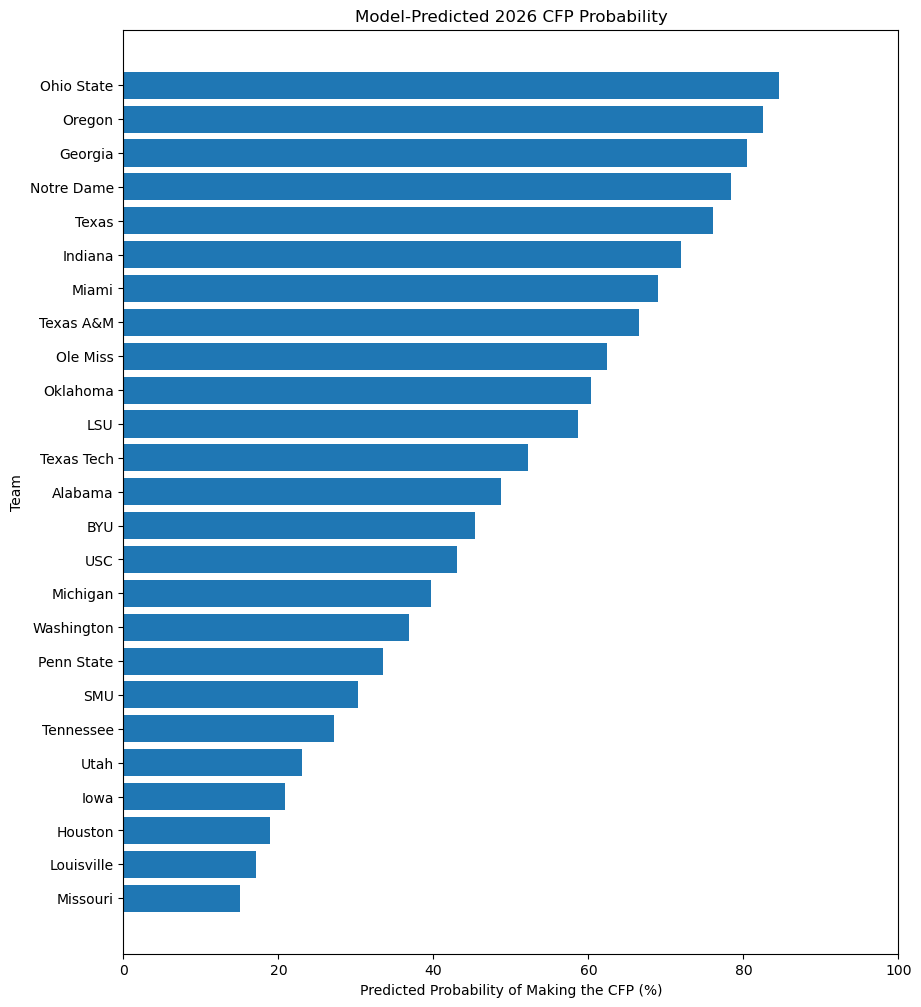

In [40]:
plt.figure(figsize=(10, 12))

plt.barh(
    predictions_2026["team"][::-1],
    predictions_2026["predicted_cfp_probability"][::-1]
)

plt.xlabel("Predicted Probability of Making the CFP (%)")
plt.ylabel("Team")
plt.title("Model-Predicted 2026 CFP Probability")

plt.xlim(0, 100)

plt.show()

In [41]:
ap_data.columns
ap_data.head()

,season,team,preseason_ap,final_ap_rank,previous_final_ap,made_playoff
0,2014,Alabama,2.0,4.0,7.0,1
1,2014,Arizona,NaN,19.0,NaN,0
2,2014,Arizona State,19.0,12.0,21.0,0
3,2014,Auburn,6.0,22.0,2.0,0
4,2014,Baylor,10.0,7.0,13.0,0


In [42]:
# Check which seasons and teams we need previous-season win totals for

wins_needed = ap_data[
    ["season", "team"]
].copy()

wins_needed["previous_season"] = wins_needed["season"] - 1

print(
    wins_needed[
        ["season", "previous_season", "team"]
    ].head(30).to_string(index=False)
)

print("\nNumber of team-seasons needed:", len(wins_needed))

 season  previous_season              team
   2014             2013           Alabama
   2014             2013           Arizona
   2014             2013     Arizona State
   2014             2013            Auburn
   2014             2013            Baylor
   2014             2013       Boise State
   2014             2013           Clemson
   2014             2013     Florida State
   2014             2013           Georgia
   2014             2013      Georgia Tech
   2014             2013      Kansas State
   2014             2013               LSU
   2014             2013        Louisville
   2014             2013          Marshall
   2014             2013           Memphis
   2014             2013    Michigan State
   2014             2013 Mississippi State
   2014             2013          Missouri
   2014             2013          Nebraska
   2014             2013    North Carolina
   2014             2013        Notre Dame
   2014             2013        Ohio State
   2014    

In [43]:
# Final modeling dataset

model_data = ap_data.copy()

# Encode unranked teams as 26
model_data["preseason_ap"] = model_data["preseason_ap"].fillna(26)
model_data["previous_final_ap"] = model_data["previous_final_ap"].fillna(26)

print("Rows:", len(model_data))
print("\nMissing values:")
print(model_data.isna().sum())

Rows: 430

Missing values:
season                 0
team                   0
preseason_ap           0
final_ap_rank        130
previous_final_ap      0
made_playoff           0
dtype: int64


In [45]:
# Show the final predictors and targets

print(
    model_data[
        [
            "season",
            "team",
            "preseason_ap",
            "previous_final_ap",
            "final_ap_rank",
            "made_playoff"
        ]
    ].head(50).to_string(index=False)
)

 season              team  preseason_ap  previous_final_ap  final_ap_rank  made_playoff
   2014           Alabama           2.0                7.0            4.0             1
   2014           Arizona          26.0               26.0           19.0             0
   2014     Arizona State          19.0               21.0           12.0             0
   2014            Auburn           6.0                2.0           22.0             0
   2014            Baylor          10.0               13.0            7.0             0
   2014       Boise State          26.0               26.0           16.0             0
   2014           Clemson          16.0                8.0           15.0             0
   2014     Florida State           1.0                1.0            5.0             1
   2014           Georgia          12.0               26.0            9.0             0
   2014      Georgia Tech          26.0               26.0            8.0             0
   2014      Kansas State       

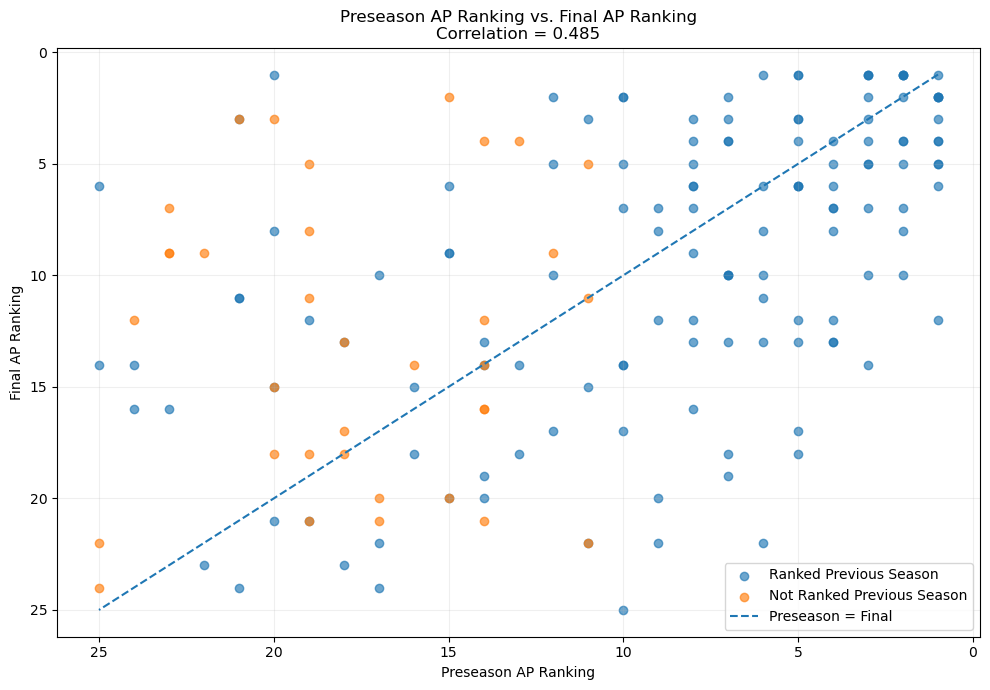

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = regression_data.copy()

plot_data["previously_ranked"] = np.where(
    plot_data["previous_final_ap"] < 26,
    "Ranked Previous Season",
    "Not Ranked Previous Season"
)

# Only include teams that had an actual preseason AP ranking
ranked_data = plot_data[
    plot_data["preseason_ap"] < 26
]

correlation = ranked_data["preseason_ap"].corr(
    ranked_data["final_ap_rank"]
)

plt.figure(figsize=(10, 7))

for group in ["Ranked Previous Season", "Not Ranked Previous Season"]:
    subset = ranked_data[
        ranked_data["previously_ranked"] == group
    ]
    
    plt.scatter(
        subset["preseason_ap"],
        subset["final_ap_rank"],
        alpha=0.65,
        label=group
    )

# Reference line: preseason rank = final rank
plt.plot(
    [1, 25],
    [1, 25],
    linestyle="--",
    label="Preseason = Final"
)

plt.xlabel("Preseason AP Ranking")
plt.ylabel("Final AP Ranking")

plt.title(
    f"Preseason AP Ranking vs. Final AP Ranking\n"
    f"Correlation = {correlation:.3f}"
)

plt.legend()
plt.grid(alpha=0.2)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

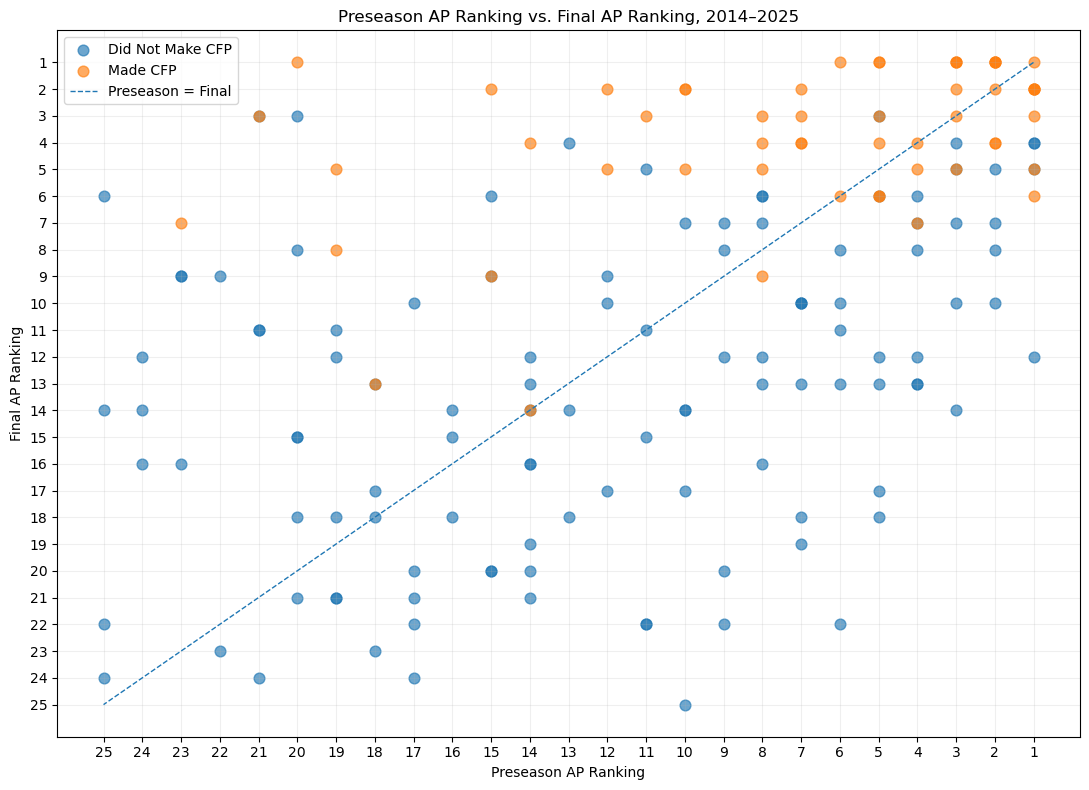

In [53]:
import matplotlib.pyplot as plt

plot_data = classification_data[
    (classification_data["preseason_ap"] < 26) &
    (classification_data["final_ap_rank"].notna())
].copy()

plt.figure(figsize=(11, 8))

for outcome, label in [
    (0, "Did Not Make CFP"),
    (1, "Made CFP")
]:
    subset = plot_data[
        plot_data["made_playoff"] == outcome
    ]

    plt.scatter(
        subset["preseason_ap"],
        subset["final_ap_rank"],
        alpha=0.65,
        s=60,
        label=label
    )

# Reference line: preseason rank = final rank
plt.plot(
    [1, 25],
    [1, 25],
    linestyle="--",
    linewidth=1,
    label="Preseason = Final"
)

plt.xlabel("Preseason AP Ranking")
plt.ylabel("Final AP Ranking")

plt.title(
    "Preseason AP Ranking vs. Final AP Ranking, 2014–2025"
)

plt.xticks(range(1, 26))
plt.yticks(range(1, 26))

# Lower number = better ranking
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
# Get the 2026 preseason AP rankings
ap_2026 = get_ap_rankings(2026)

ap_2026.head()

,season,team,preseason_ap,final_ap_rank
0,2026,Alabama,13.0,NaN
1,2026,BYU,14.0,NaN
2,2026,Georgia,3.0,NaN
3,2026,Houston,23.0,NaN
4,2026,Indiana,6.0,NaN


In [59]:
# Get 2025 final AP rankings to use as 2026 previous-year rankings
previous_2026 = ap_data[ap_data["season"] == 2025][
    ["team", "final_ap_rank"]
].copy()

previous_2026 = previous_2026.rename(
    columns={"final_ap_rank": "previous_final_ap"}
)

# Merge with 2026 preseason rankings
pred_2026 = ap_2026.merge(
    previous_2026,
    on="team",
    how="left"
)

# Treat unranked teams as 26, just as we did for the models
pred_2026["preseason_ap"] = pred_2026["preseason_ap"].fillna(26)
pred_2026["previous_final_ap"] = pred_2026["previous_final_ap"].fillna(26)

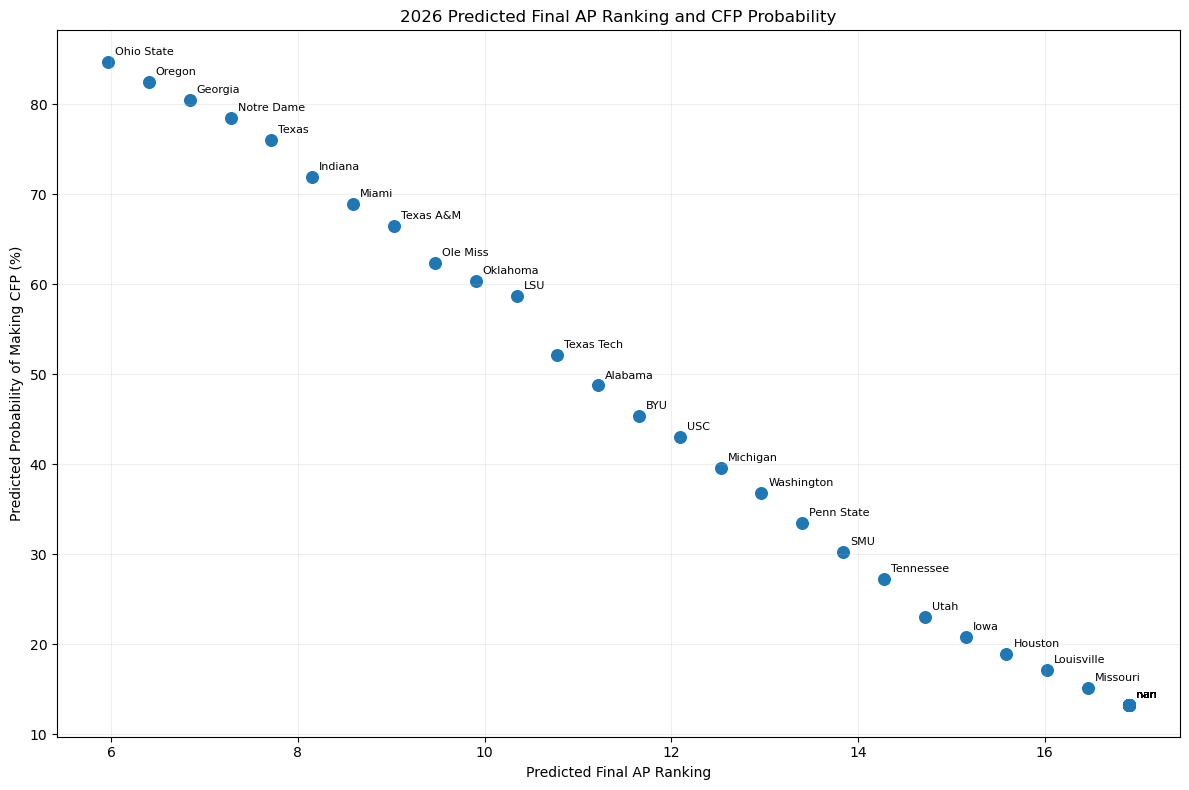

In [61]:
# Predict 2026 final AP ranking
pred_2026["predicted_final_rank"] = final_linear_model.predict(
    pred_2026[["preseason_ap", "previous_final_ap"]]
)

# Predict 2026 CFP probability
pred_2026["playoff_probability"] = (
    final_logistic_model.predict_proba(
        pred_2026[["preseason_ap", "previous_final_ap"]]
    )[:, 1] * 100
)

pred_2026 = pred_2026.sort_values(
    "playoff_probability",
    ascending=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(
    pred_2026["predicted_final_rank"],
    pred_2026["playoff_probability"],
    s=70,
    alpha=1
)

for _, row in pred_2026.iterrows():
    plt.annotate(
        row["team"],
        (row["predicted_final_rank"], row["playoff_probability"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Predicted Final AP Ranking")
plt.ylabel("Predicted Probability of Making CFP (%)")
plt.title("2026 Predicted Final AP Ranking and CFP Probability")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("preseason_vs_final.png", dpi=300, bbox_inches="tight")
plt.show()